In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import os

path = r"Task_4\data\student-mat.csv"

print("File exists:", os.path.exists(path))
print("Readable:", os.access(path, os.R_OK))

File exists: False
Readable: False


In [6]:
import os
print(os.getcwd())

c:\Users\malle\OneDrive\Desktop\Student-Performance_research\Task_4


In [9]:
import os

for root, dirs, files in os.walk(r"C:\Users\malle\OneDrive\Desktop\Student-Performance_research"):
    for file in files:
        if file.lower() == "student-mat.csv":
            print(os.path.join(root, file))

In [13]:
df = pd.read_csv(r"..\data\student-mat (1).csv", sep=";")

In [14]:
df.shape

(395, 33)

In [11]:
df.head()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0,"GP;""F"";18;""U"";""GT3"";""A"";4;4;""at_home"";""teacher..."
1,"GP;""F"";17;""U"";""GT3"";""T"";1;1;""at_home"";""other"";..."
2,"GP;""F"";15;""U"";""LE3"";""T"";1;1;""at_home"";""other"";..."
3,"GP;""F"";15;""U"";""GT3"";""T"";4;2;""health"";""services..."
4,"GP;""F"";16;""U"";""GT3"";""T"";3;3;""other"";""other"";""h..."


In [15]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [16]:
numeric_features = df.select_dtypes(include=np.number)

numeric_features.shape

(395, 16)

In [18]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 2.4 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/8.9 MB 2.6 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/8.9 MB 1.9 MB/s eta 0:00:04
   -------- ------------------------------- 1.8/8.9 MB 2.1 MB/s eta 0:00:04
   ---------- ----------------------------- 2.4/8.9 MB 2.2 MB/s eta 0:00:04
   -------------- ------------------------- 3.1/8.9 MB 2.4 MB/s eta 0:00:03
   --------------- ------------------------ 3.4/8.9 MB 2.3 MB/s eta 0:00:03
   -------------------- ------------------- 4.5/8.9 MB 2.6 MB/s eta 0:00:02
   ----------------------- ---------------- 5.2/8.9 MB 2.7 MB/s eta 0:00:02
   ---------------------------- ----------- 6.3/8.9 MB 2.9 MB/s eta 0:00:01
   ------------------------------- -------- 7.1/8.9 MB 3.0 MB/s eta 0:00:01
   -----------------------

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_features)

X_scaled.shape

(395, 16)

In [20]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(395, 16)

In [21]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.21222531 0.13077091 0.09735655 0.07998059 0.07310184 0.06329616
 0.05815798 0.05615591 0.04812073 0.04481495 0.03963004 0.03871016
 0.02275481 0.01843942 0.01148019 0.00500445]


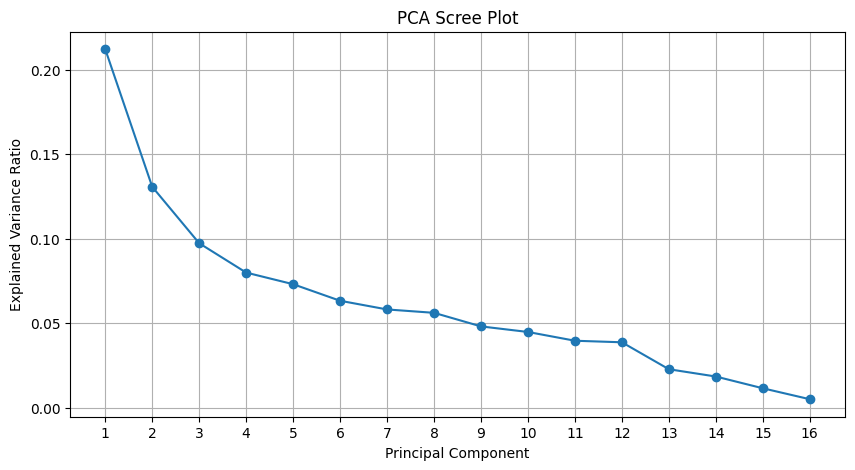

In [22]:
plt.figure(figsize=(10, 5))

components = range(1, len(explained_variance) + 1)

plt.plot(components, explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.xticks(components)
plt.grid(True)

plt.show()

In [23]:
cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance)

[0.21222531 0.34299622 0.44035277 0.52033336 0.59343521 0.65673136
 0.71488934 0.77104524 0.81916598 0.86398093 0.90361097 0.94232113
 0.96507594 0.98351536 0.99499555 1.        ]


In [24]:
pca_90 = PCA(n_components=0.90)
X_pca_90 = pca_90.fit_transform(X_scaled)

print("Number of components:", X_pca_90.shape[1])
print("Reduced data shape:", X_pca_90.shape)

Number of components: 11
Reduced data shape: (395, 11)


In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_90)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_90, labels))

print("Inertias:", inertias)
print("Silhouette Scores:", silhouette_scores)

Inertias: [4851.832954557165, 4414.9504962857845, 4106.85139116761, 3887.8215514161047, 3723.8447520041154, 3606.0641793822097, 3471.212515340631, 3376.175125847296, 3288.633698375063]
Silhouette Scores: [0.14773500305860252, 0.13247891502359688, 0.11298619875942342, 0.10647437331843654, 0.10694715678013746, 0.09650124269043742, 0.09717197250882897, 0.0904619475207394, 0.09482396207078786]


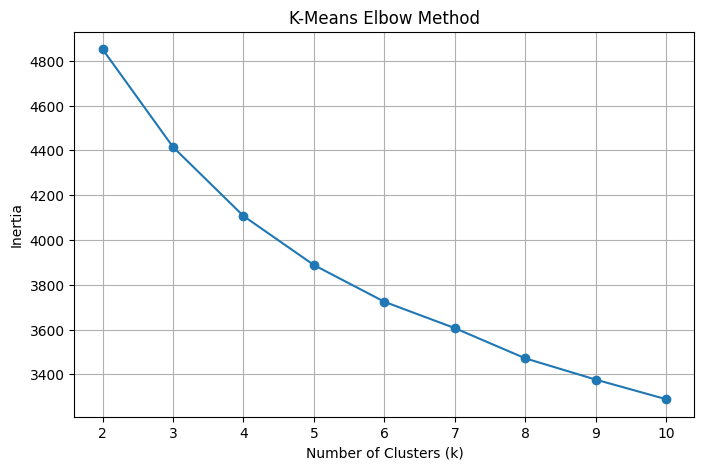

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertias, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")

plt.grid(True)
plt.show()

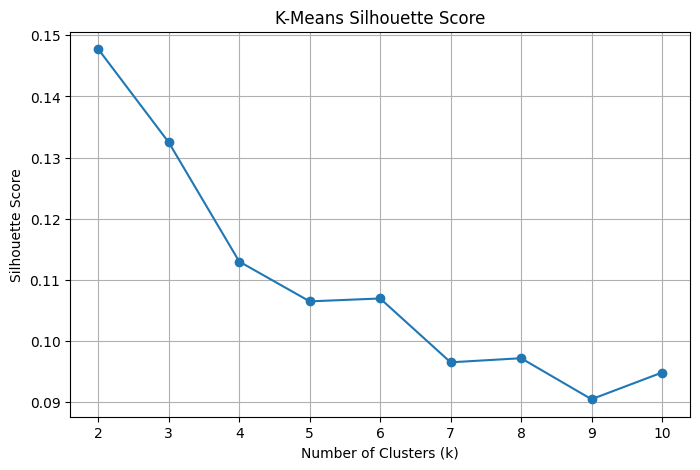

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score")

plt.grid(True)
plt.show()

In [28]:
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)

kmeans_labels = kmeans_final.fit_predict(X_pca_90)

print("Cluster labels:", kmeans_labels)
print("Number of clusters:", len(set(kmeans_labels)))

Cluster labels: [1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0
 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0
 0 0 0 0 1 1 0 0 1 0 1 1 1 0 1 1 1 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 1 1 0 0 1 1 1 1 0 0 1 1 0 0 1 1 1 0
 1 1 1 1 1 1 0 0 0 1 0 1 1 1 1 1 1 0 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 0 1 0
 0 0 0 1 1 0 1 1 1 0 0 0 1 0 0 0 1 1 1 0 1 1 0 1 1 1 0 0 1 0 0 1 1 1 0 1 1
 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 0 0
 1 0 0 0 0 1 0 1 0 1 1 1 0 1 0 0 0 1 1 1 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1
 1 1 0 0 1 0 1 1 1 0 1 0 0 0 1 0 1 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0
 1 0 0 1 0 1 0 1 0 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1]
Number of clusters: 2


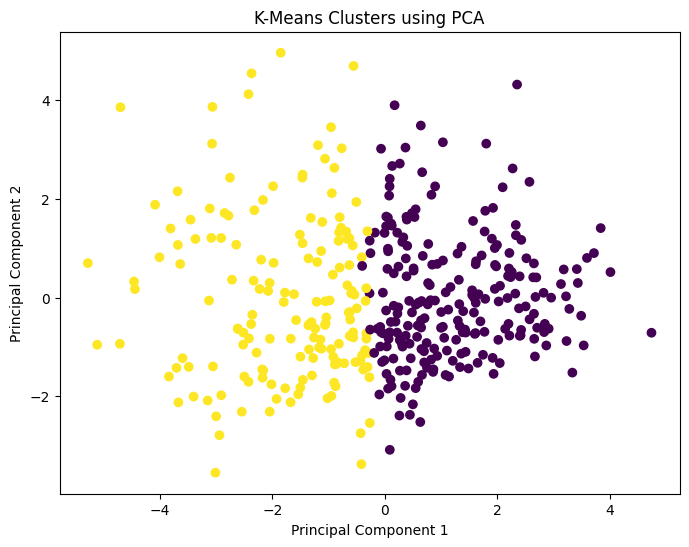

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_90[:, 0],
    X_pca_90[:, 1],
    c=kmeans_labels,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters using PCA")

plt.show()

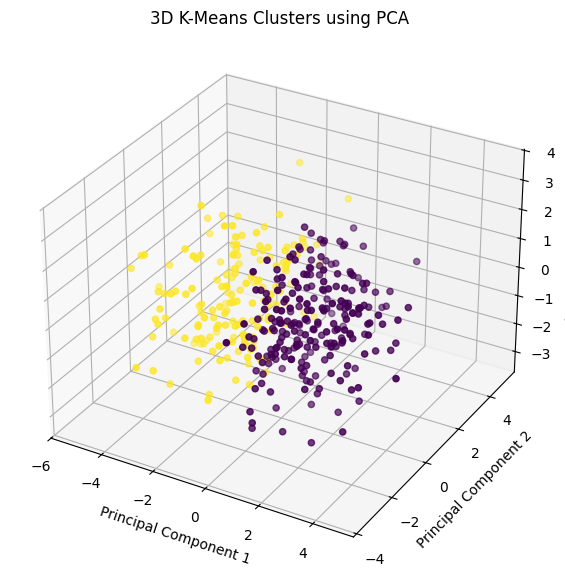

In [30]:
fig = plt.figure(figsize=(9, 7))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca_90[:, 0],
    X_pca_90[:, 1],
    X_pca_90[:, 2],
    c=kmeans_labels,
    cmap="viridis"
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D K-Means Clusters using PCA")

plt.show()

In [34]:
dbscan = DBSCAN(eps=3.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_pca_90)

print("DBSCAN cluster labels:", dbscan_labels)
print("Number of clusters:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Number of noise points:", list(dbscan_labels).count(-1))

DBSCAN cluster labels: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0  0
  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0 -1  0  0  0  0  0  0  0 -1  0  0  0  0  0  0 -1  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 

In [35]:
X_pca_2d = X_pca_90[:, :2]

dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_pca_2d)

print("Number of clusters:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Number of noise points:", list(dbscan_labels).count(-1))

Number of clusters: 5
Number of noise points: 40


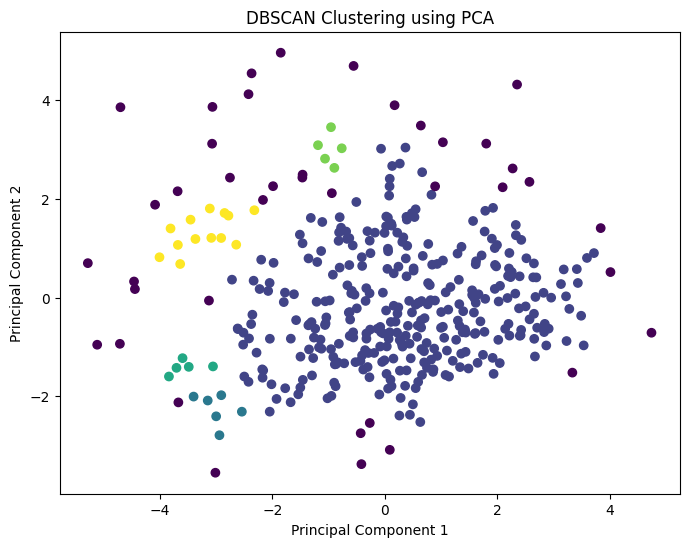

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=dbscan_labels,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering using PCA")

plt.show()

In [37]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=2)

hierarchical_labels = hierarchical.fit_predict(X_pca_90)

print("Number of clusters:", len(set(hierarchical_labels)))
print("Cluster labels:", hierarchical_labels)

Number of clusters: 2
Cluster labels: [1 0 0 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 1 0 0 1 1 1 1 0 1
 1 1 0 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 1 0 1 1
 0 0 1 0 1 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 1 0 1 1 0 1
 0 0 0 0 0 1 0 0 0 1 1 1 0 1 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0
 1 0 1 0 1 1 0 0 1 1 1 1 0 1 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 1 1
 0 1 1 1 0 0 1 0 1 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 0 0 1 0 0 0 1 1 0 0 0 1 0 1 0
 0 0 1 1 0 1 0 1 1 1 0 0 1 1 0 1 0 0 1 0 0 1 0 1 0 0 0 0 1 1 1 0 0 1 0 1 1
 0 0 0 0 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0]


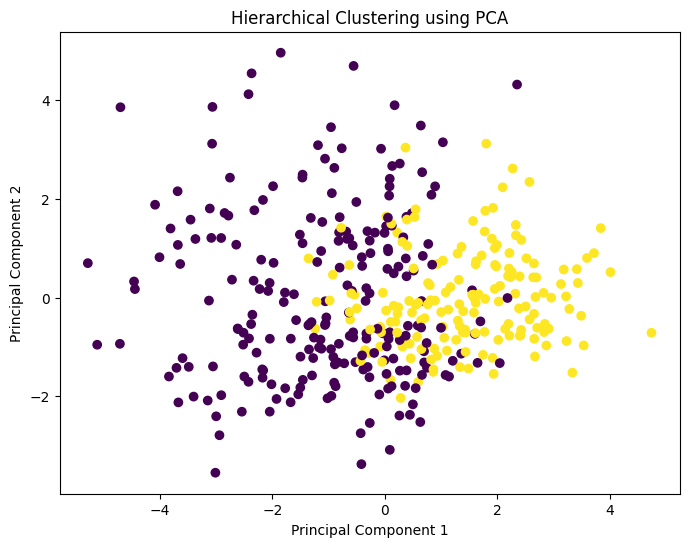

In [38]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=hierarchical_labels,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clustering using PCA")

plt.show()

In [39]:
hierarchical_silhouette = silhouette_score(
    X_pca_90,
    hierarchical_labels
)

print("Hierarchical Clustering Silhouette Score:", hierarchical_silhouette)

Hierarchical Clustering Silhouette Score: 0.0932314109188613


In [40]:
kmeans_silhouette = silhouette_score(
    X_pca_90,
    kmeans_labels
)

print("K-Means Silhouette Score:", kmeans_silhouette)

K-Means Silhouette Score: 0.14773500305860252


In [41]:
dbscan_silhouette = silhouette_score(
    X_pca_2d[dbscan_labels != -1],
    dbscan_labels[dbscan_labels != -1]
)

print("DBSCAN Silhouette Score:", dbscan_silhouette)

DBSCAN Silhouette Score: 0.23117401277521163


In [42]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN", "Hierarchical"],
    "Silhouette Score": [
        kmeans_silhouette,
        dbscan_silhouette,
        hierarchical_silhouette
    ]
})

comparison

,Algorithm,Silhouette Score
0,K-Means,0.147735
1,DBSCAN,0.231174
2,Hierarchical,0.093231


## Conclusion

PCA was applied to the standardized numerical features of the Student Performance dataset. The first 11 principal components retained approximately 90.36% of the total variance.

Three unsupervised clustering techniques were applied: K-Means, DBSCAN, and Hierarchical Clustering. K-Means produced 2 clusters, DBSCAN identified 5 clusters with 40 noise points, and Hierarchical Clustering produced 2 clusters.

Based on the silhouette scores, DBSCAN achieved the highest score (0.2312), followed by K-Means (0.1477) and Hierarchical Clustering (0.0932). Therefore, DBSCAN provided the best cluster separation among the three methods for this analysis.